In [95]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split

%matplotlib inline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [73]:
train_df = pd.read_csv('../data/forest_train.csv')
test_df = pd.read_csv('../data/forest_test.csv')

In [93]:
def write_to_submission_file(
        predicted_labels,
        out_file,
        target="Cover_Type",
        index_label="Id",
        init_index=15121
    ):
    predicted_df = pd.DataFrame(
        predicted_labels,
        index=np.arange(init_index, predicted_labels.shape[0] + init_index),
        columns=[target],
    )
    predicted_df.to_csv(out_file, index_label=index_label)

# Создание признаков

In [75]:
train_df["Under_water"] = train_df.Vertical_Distance_To_Hydrology < 0
test_df["Under_water"] = test_df.Vertical_Distance_To_Hydrology < 0

train_df["EVDtH"] = train_df.Elevation - train_df.Vertical_Distance_To_Hydrology
test_df["EVDtH"] = test_df.Elevation - test_df.Vertical_Distance_To_Hydrology

train_df["EHDtH"] = train_df.Elevation - train_df.Horizontal_Distance_To_Hydrology * 0.2
test_df["EHDtH"] = test_df.Elevation - test_df.Horizontal_Distance_To_Hydrology * 0.2

train_df["Distanse_to_Hydrolody"] = (
    train_df["Horizontal_Distance_To_Hydrology"] ** 2
    + train_df["Vertical_Distance_To_Hydrology"] ** 2
) ** 0.5
test_df["Distanse_to_Hydrolody"] = (
    test_df["Horizontal_Distance_To_Hydrology"] ** 2
    + test_df["Vertical_Distance_To_Hydrology"] ** 2
) ** 0.5

train_df["Hydro_Fire_1"] = (
    train_df["Horizontal_Distance_To_Hydrology"]
    + train_df["Horizontal_Distance_To_Fire_Points"]
)
test_df["Hydro_Fire_1"] = (
    test_df["Horizontal_Distance_To_Hydrology"]
    + test_df["Horizontal_Distance_To_Fire_Points"]
)

train_df["Hydro_Fire_2"] = abs(
    train_df["Horizontal_Distance_To_Hydrology"]
    - train_df["Horizontal_Distance_To_Fire_Points"]
)
test_df["Hydro_Fire_2"] = abs(
    test_df["Horizontal_Distance_To_Hydrology"]
    - test_df["Horizontal_Distance_To_Fire_Points"]
)

train_df["Hydro_Road_1"] = abs(
    train_df["Horizontal_Distance_To_Hydrology"]
    + train_df["Horizontal_Distance_To_Roadways"]
)
test_df["Hydro_Road_1"] = abs(
    test_df["Horizontal_Distance_To_Hydrology"]
    + test_df["Horizontal_Distance_To_Roadways"]
)

train_df["Hydro_Road_2"] = abs(
    train_df["Horizontal_Distance_To_Hydrology"]
    - train_df["Horizontal_Distance_To_Roadways"]
)
test_df["Hydro_Road_2"] = abs(
    test_df["Horizontal_Distance_To_Hydrology"]
    - test_df["Horizontal_Distance_To_Roadways"]
)

train_df["Fire_Road_1"] = abs(
    train_df["Horizontal_Distance_To_Fire_Points"]
    + train_df["Horizontal_Distance_To_Roadways"]
)
test_df["Fire_Road_1"] = abs(
    test_df["Horizontal_Distance_To_Fire_Points"]
    + test_df["Horizontal_Distance_To_Roadways"]
)

train_df["Fire_Road_2"] = abs(
    train_df["Horizontal_Distance_To_Fire_Points"]
    - train_df["Horizontal_Distance_To_Roadways"]
)
test_df["Fire_Road_2"] = abs(
    test_df["Horizontal_Distance_To_Fire_Points"]
    - test_df["Horizontal_Distance_To_Roadways"]
)

In [76]:
y = train_df["Cover_Type"]
train_df = train_df.drop(["Cover_Type", "Id"], axis=1)
test_df = test_df.drop(["Id"], axis=1)

y = y - 1  # Чтоб классы нумеровались от о до 6

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    train_df, y, test_size=0.3, random_state=17
)

In [78]:
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe

In [79]:
def score(params):
    from sklearn.metrics import log_loss

    print("Training with params:")
    print(params)
    params["max_depth"] = int(params["max_depth"])
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_test, label=y_test)
    model = xgb.train(params, dtrain, params["num_round"])
    predictions = model.predict(dvalid).reshape((X_test.shape[0], 7))
    score = log_loss(y_test, predictions)
    print("\tScore {0}\n\n".format(score))
    return {"loss": score, "status": STATUS_OK}

In [80]:
def optimize(trials):
    space = {
        "num_round": 100,
        "learning_rate": hp.quniform("eta", 0.005, 0.05, 0.005),
        "max_depth": hp.quniform("max_depth", 3, 14, 1),
        "min_child_weight": hp.quniform("min_child_weight", 1, 10, 1),
        "subsample": hp.quniform("subsample", 0.5, 1, 0.05),
        "gamma": hp.quniform("gamma", 0.5, 1, 0.01),
        "colsample_bytree": hp.quniform("colsample_bytree", 0.4, 1, 0.05),
        "num_class": 7,
        "eval_metric": "merror",
        "objective": "multi:softprob",
        "nthread": 4,
        "silent": 1,
    }

    best = fmin(score, space, algo=tpe.suggest, trials=trials, max_evals=10)
    return best

In [81]:
trials = Trials()
best_params = optimize(trials)
best_params

Training with params:                                 
{'colsample_bytree': 0.6000000000000001, 'eval_metric': 'merror', 'gamma': 0.9500000000000001, 'learning_rate': 0.035, 'max_depth': 10.0, 'min_child_weight': 10.0, 'nthread': 4, 'num_class': 7, 'num_round': 100, 'objective': 'multi:softprob', 'silent': 1, 'subsample': 0.9}
	Score 0.499498411144423                              


Training with params:                                                          
{'colsample_bytree': 0.45, 'eval_metric': 'merror', 'gamma': 0.99, 'learning_rate': 0.02, 'max_depth': 8.0, 'min_child_weight': 4.0, 'nthread': 4, 'num_class': 7, 'num_round': 100, 'objective': 'multi:softprob', 'silent': 1, 'subsample': 0.75}
	Score 0.7117551572944706                                                      


Training with params:                                                          
{'colsample_bytree': 1.0, 'eval_metric': 'merror', 'gamma': 0.96, 'learning_rate': 0.03, 'max_depth': 4.0, 'min_child_weight': 6

{'colsample_bytree': np.float64(0.45),
 'eta': np.float64(0.045),
 'gamma': np.float64(0.99),
 'max_depth': np.float64(13.0),
 'min_child_weight': np.float64(4.0),
 'subsample': np.float64(0.65)}

In [82]:
best_params["max_depth"] = int(best_params["max_depth"])
best_params["num_class"] = 7
best_params["eval_metric"] = "merror"
best_params["objective"] = "multi:softprob"
best_params["nthread"] = 4
best_params["silent"] = 1

In [83]:
dtrain = xgb.DMatrix(train_df, y)

In [84]:
%%time
xgbCvResult = xgb.cv(
    best_params, dtrain, num_boost_round=500, nfold=3, early_stopping_rounds=50
)

CPU times: user 37.8 s, sys: 4.12 s, total: 42 s
Wall time: 20.5 s


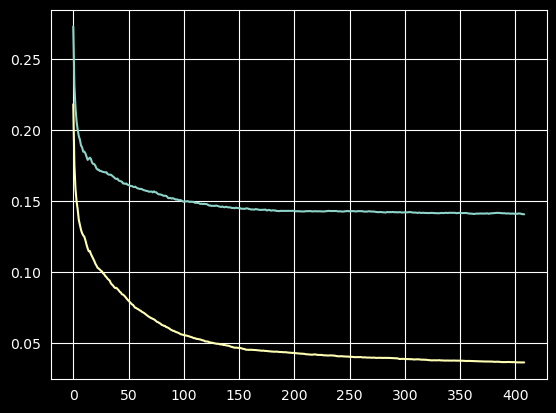

In [85]:
plt.plot(range(xgbCvResult.shape[0]), xgbCvResult["test-merror-mean"])
plt.plot(range(xgbCvResult.shape[0]), xgbCvResult["train-merror-mean"]);

In [86]:
best_num_round = np.argmin(xgbCvResult["test-merror-mean"])
best_num_round

np.int64(408)

In [87]:
bestXgb = xgb.train(best_params, dtrain, num_boost_round=best_num_round)

In [88]:
dtest = xgb.DMatrix(test_df)

In [89]:
xgboost_predict_proba = bestXgb.predict(dtest)

In [90]:
xgboost_prediction = np.argmax(xgboost_predict_proba, axis=1)

In [91]:
xgboost_prediction += 1

In [94]:
write_to_submission_file(xgboost_prediction, "forest_cover_type_xgboost.csv")